In [2]:
import math
import random
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer
from sklearn.model_selection import KFold

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
print("PyTorch version:", torch.__version__)

Using device: cpu
PyTorch version: 2.12.0+cpu


In [4]:
raw_dataset = load_dataset("Helsinki-NLP/opus_books", "en-fr")

print(raw_dataset)
print(raw_dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['id', 'translation'],
        num_rows: 127085
    })
})
{'id': '0', 'translation': {'en': 'The Wanderer', 'fr': 'Le grand Meaulnes'}}


In [5]:
tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-fr")

pad_token_id = tokenizer.pad_token_id
eos_token_id = tokenizer.eos_token_id

print("Vocabulary size:", len(tokenizer))
print("PAD token ID:", pad_token_id)
print("EOS token ID:", eos_token_id)

Vocabulary size: 59514
PAD token ID: 59513
EOS token ID: 0


In [6]:
# Dataset settings
subset_size = 3000
k_folds = 5

# Training settings
num_epochs = 3
batch_size = 32
max_seq_length = 64
learning_rate = 0.0003

# Transformer settings
d_model = 256
num_heads = 4
num_layers = 3
d_ff = 512
dropout = 0.1

# Reproducibility
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [7]:
small_dataset = raw_dataset["train"].shuffle(seed=seed).select(range(subset_size))

print("Subset size:", len(small_dataset))
print(small_dataset[0])

Subset size: 3000
{'id': '44126', 'translation': {'en': '"Not if it were my own brother!" cried d’Artagnan, as if carried away by his enthusiasm.', 'fr': "«Non, fût-ce mon frère!» s'écria d'Artagnan comme emporté par l'enthousiasme."}}


In [8]:
class TranslationDataset(Dataset):
    def __init__(self, dataset, tokenizer, max_length=64):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.max_length = max_length

        self.pad_token_id = tokenizer.pad_token_id
        self.eos_token_id = tokenizer.eos_token_id

    def __len__(self):
        return len(self.dataset)

    def encode_source(self, text):
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return encoding["input_ids"].squeeze(0)

    def encode_target_with_start_token(self, text):
        # Tokenize target without padding first
        encoding = self.tokenizer(
            text,
            max_length=self.max_length - 1,
            padding=False,
            truncation=True,
            return_tensors=None
        )

        target_ids = encoding["input_ids"]

        # Add decoder start token at the beginning
        target_ids = [self.pad_token_id] + target_ids

        # Pad manually to max_length
        if len(target_ids) < self.max_length:
            target_ids = target_ids + [self.pad_token_id] * (self.max_length - len(target_ids))
        else:
            target_ids = target_ids[:self.max_length]

        return torch.tensor(target_ids, dtype=torch.long)

    def __getitem__(self, idx):
        example = self.dataset[idx]["translation"]

        src_text = example["en"]
        tgt_text = example["fr"]

        src_ids = self.encode_source(src_text)
        tgt_ids = self.encode_target_with_start_token(tgt_text)

        return {
            "src_ids": src_ids,
            "tgt_ids": tgt_ids,
            "src_text": src_text,
            "tgt_text": tgt_text
        }

In [31]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        batch_size, seq_length, d_model = x.size()

        x = x.view(batch_size, seq_length, self.num_heads, self.d_k)

        return x.transpose(1, 2)

    def combine_heads(self, x):
        batch_size, num_heads, seq_length, d_k = x.size()

        x = x.transpose(1, 2).contiguous()

        return x.view(batch_size, seq_length, self.d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = torch.softmax(scores, dim=-1)

        output = torch.matmul(attention_weights, V)

        return output

    def forward(self, Q, K, V, mask=None):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))

        attention_output = self.scaled_dot_product_attention(Q, K, V, mask)

        output = self.W_o(self.combine_heads(attention_output))

        return output

In [32]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))
    

In [33]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super().__init__()

        pe = torch.zeros(max_seq_length, d_model)

        position = torch.arange(
            0,
            max_seq_length,
            dtype=torch.float
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_length = x.size(1)

        return x + self.pe[:, :seq_length, :]

In [34]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()

        self.self_attention = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        attention_output = self.self_attention(x, x, x, src_mask)

        x = self.norm1(x + self.dropout(attention_output))

        ff_output = self.feed_forward(x)

        x = self.norm2(x + self.dropout(ff_output))

        return x

In [35]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()

        self.self_attention = MultiHeadAttention(d_model, num_heads)
        self.cross_attention = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        self_attention_output = self.self_attention(x, x, x, tgt_mask)

        x = self.norm1(x + self.dropout(self_attention_output))

        cross_attention_output = self.cross_attention(
            x,
            encoder_output,
            encoder_output,
            src_mask
        )

        x = self.norm2(x + self.dropout(cross_attention_output))

        ff_output = self.feed_forward(x)

        x = self.norm3(x + self.dropout(ff_output))

        return x

In [36]:
class Transformer(nn.Module):
    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        d_model,
        num_heads,
        num_layers,
        d_ff,
        max_seq_length,
        dropout,
        pad_token_id
    ):
        super().__init__()

        self.src_embedding = nn.Embedding(
            src_vocab_size,
            d_model,
            padding_idx=pad_token_id
        )

        self.tgt_embedding = nn.Embedding(
            tgt_vocab_size,
            d_model,
            padding_idx=pad_token_id
        )

        self.positional_encoding = PositionalEncoding(
            d_model,
            max_seq_length
        )

        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

        self.dropout = nn.Dropout(dropout)

        self.pad_token_id = pad_token_id

    def generate_mask(self, src, tgt):
        src_mask = (src != self.pad_token_id).unsqueeze(1).unsqueeze(2)

        tgt_padding_mask = (tgt != self.pad_token_id).unsqueeze(1).unsqueeze(3)

        tgt_seq_length = tgt.size(1)

        nopeak_mask = torch.tril(
            torch.ones(
                1,
                1,
                tgt_seq_length,
                tgt_seq_length,
                device=tgt.device
            )
        ).bool()

        tgt_mask = tgt_padding_mask & nopeak_mask

        return src_mask, tgt_mask

    def forward(self, src, tgt):
        src_mask, tgt_mask = self.generate_mask(src, tgt)

        src_embedded = self.dropout(
            self.positional_encoding(self.src_embedding(src))
        )

        tgt_embedded = self.dropout(
            self.positional_encoding(self.tgt_embedding(tgt))
        )

        encoder_output = src_embedded

        for encoder_layer in self.encoder_layers:
            encoder_output = encoder_layer(encoder_output, src_mask)

        decoder_output = tgt_embedded

        for decoder_layer in self.decoder_layers:
            decoder_output = decoder_layer(
                decoder_output,
                encoder_output,
                src_mask,
                tgt_mask
            )

        output = self.fc_out(decoder_output)

        return output

In [37]:
def create_model():
    model = Transformer(
        src_vocab_size=len(tokenizer),
        tgt_vocab_size=len(tokenizer),
        d_model=d_model,
        num_heads=num_heads,
        num_layers=num_layers,
        d_ff=d_ff,
        max_seq_length=max_seq_length,
        dropout=dropout,
        pad_token_id=pad_token_id
    ).to(device)

    return model

In [38]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()

    total_loss = 0

    for batch in dataloader:
        src = batch["src_ids"].to(device)
        tgt = batch["tgt_ids"].to(device)

        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        optimizer.zero_grad()

        predictions = model(src, tgt_input)

        loss = criterion(
            predictions.reshape(-1, predictions.size(-1)),
            tgt_output.reshape(-1)
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [39]:
def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            src = batch["src_ids"].to(device)
            tgt = batch["tgt_ids"].to(device)

            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]

            predictions = model(src, tgt_input)

            loss = criterion(
                predictions.reshape(-1, predictions.size(-1)),
                tgt_output.reshape(-1)
            )

            total_loss += loss.item()

    return total_loss / len(dataloader)

In [40]:
kf = KFold(
    n_splits=k_folds,
    shuffle=True,
    random_state=seed
)

indices = np.arange(len(small_dataset))

fold_results = []
fold_train_losses = []
fold_val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(indices)):
    print("=" * 80)
    print(f"Fold {fold + 1}/{k_folds}")
    print("=" * 80)

    train_subset = small_dataset.select(train_idx.tolist())
    val_subset = small_dataset.select(val_idx.tolist())

    train_dataset = TranslationDataset(
        train_subset,
        tokenizer,
        max_length=max_seq_length
    )

    val_dataset = TranslationDataset(
        val_subset,
        tokenizer,
        max_length=max_seq_length
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    model = create_model()

    criterion = nn.CrossEntropyLoss(ignore_index=pad_token_id)

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate,
        betas=(0.9, 0.98),
        eps=1e-9
    )

    best_val_loss = float("inf")

    current_fold_train_losses = []
    current_fold_val_losses = []

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device
        )

        val_loss = evaluate(
            model,
            val_loader,
            criterion,
            device
        )

        current_fold_train_losses.append(train_loss)
        current_fold_val_losses.append(val_loss)

        print(f"Fold {fold + 1}, Epoch {epoch + 1}/{num_epochs}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss:   {val_loss:.4f}")
        print("-" * 40)

        if val_loss < best_val_loss:
            best_val_loss = val_loss

            torch.save(
                model.state_dict(),
                f"best_transformer_fold_{fold + 1}.pth"
            )

    fold_results.append(best_val_loss)
    fold_train_losses.append(current_fold_train_losses)
    fold_val_losses.append(current_fold_val_losses)

    print(f"Best validation loss for fold {fold + 1}: {best_val_loss:.4f}")

Fold 1/5
Fold 1, Epoch 1/3
Train Loss: 7.7092
Val Loss:   6.2149
----------------------------------------
Fold 1, Epoch 2/3
Train Loss: 5.8338
Val Loss:   5.5766
----------------------------------------
Fold 1, Epoch 3/3
Train Loss: 5.2777
Val Loss:   5.1790
----------------------------------------
Best validation loss for fold 1: 5.1790
Fold 2/5
Fold 2, Epoch 1/3
Train Loss: 7.7447
Val Loss:   6.2089
----------------------------------------
Fold 2, Epoch 2/3
Train Loss: 5.8235
Val Loss:   5.5584
----------------------------------------
Fold 2, Epoch 3/3
Train Loss: 5.2522
Val Loss:   5.1348
----------------------------------------
Best validation loss for fold 2: 5.1348
Fold 3/5
Fold 3, Epoch 1/3
Train Loss: 7.6955
Val Loss:   6.1587
----------------------------------------
Fold 3, Epoch 2/3
Train Loss: 5.7951
Val Loss:   5.5451
----------------------------------------
Fold 3, Epoch 3/3
Train Loss: 5.2457
Val Loss:   5.1524
----------------------------------------
Best validation loss

In [41]:
print("=" * 80)
print("K-Fold Validation Results")
print("=" * 80)

for fold, loss in enumerate(fold_results):
    print(f"Fold {fold + 1}: Best Val Loss = {loss:.4f}")

mean_loss = np.mean(fold_results)
std_loss = np.std(fold_results)

print("-" * 40)
print(f"Average Validation Loss: {mean_loss:.4f}")
print(f"Standard Deviation:      {std_loss:.4f}")

K-Fold Validation Results
Fold 1: Best Val Loss = 5.1790
Fold 2: Best Val Loss = 5.1348
Fold 3: Best Val Loss = 5.1524
Fold 4: Best Val Loss = 5.1788
Fold 5: Best Val Loss = 5.1240
----------------------------------------
Average Validation Loss: 5.1538
Standard Deviation:      0.0224


In [42]:
best_fold = np.argmin(fold_results) + 1

print("Best fold:", best_fold)
print("Best validation loss:", fold_results[best_fold - 1])

best_model = create_model()

best_model.load_state_dict(
    torch.load(
        f"best_transformer_fold_{best_fold}.pth",
        map_location=device
    )
)

best_model.eval()

print("Best model loaded.")

Best fold: 5
Best validation loss: 5.1240411808616235
Best model loaded.


In [43]:
def translate_sentence(sentence, model, tokenizer, device, max_length=64):
    model.eval()

    src_encoding = tokenizer(
        sentence,
        max_length=max_length,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    src = src_encoding["input_ids"].to(device)

    decoder_input = torch.tensor(
        [[tokenizer.pad_token_id]],
        dtype=torch.long,
        device=device
    )

    with torch.no_grad():
        for _ in range(max_length - 1):
            output = model(src, decoder_input)

            next_token_logits = output[:, -1, :]

            next_token_id = next_token_logits.argmax(dim=-1).unsqueeze(1)

            decoder_input = torch.cat(
                [decoder_input, next_token_id],
                dim=1
            )

            if next_token_id.item() == tokenizer.eos_token_id:
                break

    translated_text = tokenizer.decode(
        decoder_input.squeeze(),
        skip_special_tokens=True
    )

    return translated_text

In [45]:
test_sentences = [
    "I am happy.",
    "I love reading books.",
    "Where are you going?",
    "This is a small transformer model.",
    "The weather is very nice today."
]

for sentence in test_sentences:
    translation = translate_sentence(
        sentence,
        best_model,
        tokenizer,
        device,
        max_length=max_seq_length
    )

    print("English:", sentence)
    print("French prediction:", translation)
    print("-" * 50)

English: I am happy.
French prediction: 'était pas.
--------------------------------------------------
English: I love reading books.
French prediction: s.
--------------------------------------------------
English: Where are you going?
French prediction: 'est-il vous vous vous.
--------------------------------------------------
English: This is a small transformer model.
French prediction: s.
--------------------------------------------------
English: The weather is very nice today.
French prediction: s.
--------------------------------------------------


In [47]:
def show_examples_from_dataset(model, dataset, tokenizer, device, num_examples=5):
    model.eval()

    random_indices = random.sample(range(len(dataset)), num_examples)

    for idx in random_indices:
        example = dataset[idx]["translation"]

        english = example["en"]
        actual_french = example["fr"]

        predicted_french = translate_sentence(
            english,
            model,
            tokenizer,
            device,
            max_length=max_seq_length
        )

        print("English:")
        print(english)
        print()
        print("Actual French:")
        print(actual_french)
        print()
        print("Predicted French:")
        print(predicted_french)
        print("=" * 80)

In [48]:
# Re-create the validation set for the best fold
all_splits = list(kf.split(indices))

best_train_idx, best_val_idx = all_splits[best_fold - 1]

best_val_subset = small_dataset.select(best_val_idx.tolist())

show_examples_from_dataset(
    best_model,
    best_val_subset,
    tokenizer,
    device,
    num_examples=5
)

English:
"Here she comes!

Actual French:
--La voilà.

Predicted French:
-- C'était-il.
English:
"Hear the end.

Actual French:
En treize coups!

Predicted French:
-- Vous.
English:
Some years after I had broken with the mother, she abandoned her child, and ran away to Italy with a musician or singer.

Actual French:
Quelques années après notre rupture, sa mère l'abandonna et s'enfuit en Italie avec un musicien ou un chanteur.

Predicted French:
'était qu'il, et je ne s'était de la qu'il, et de la qu'il, et de la qu'il, et de la qu'il, et de la qu'il.
English:
And who can say that in two months' time, after a long confinement in this damp cell, I shall be so well prepared?

Actual French:
Et qui me dit que dans deux mois, après un long séjour dans ce cachot humide, je serai aussi bien disposé?

Predicted French:
'était qu'il, je ne vous qu'il, je ne vous avait pas, et je ne vous qu'il, et je ne s'il.
English:
The delicate sensibility of balloons is well known.

Actual French:
On sait d

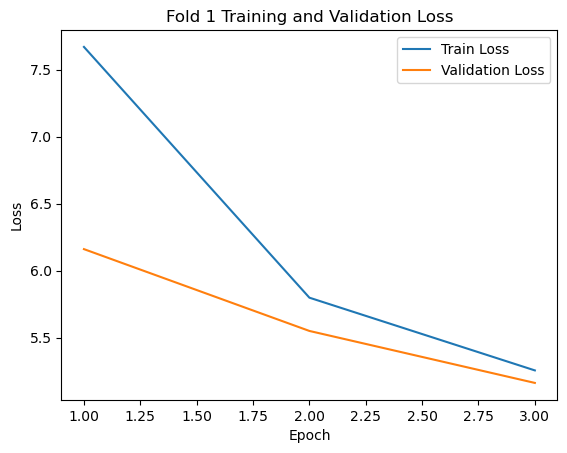

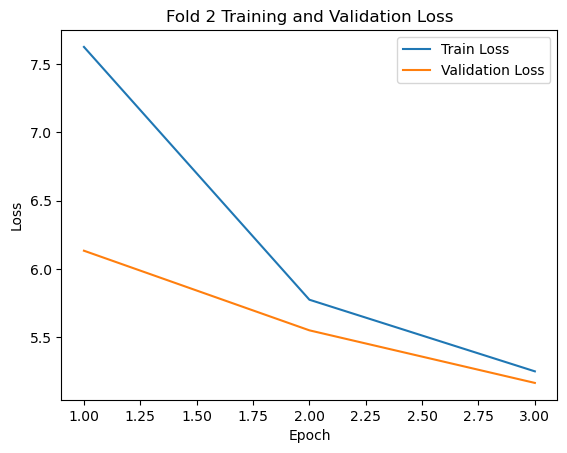

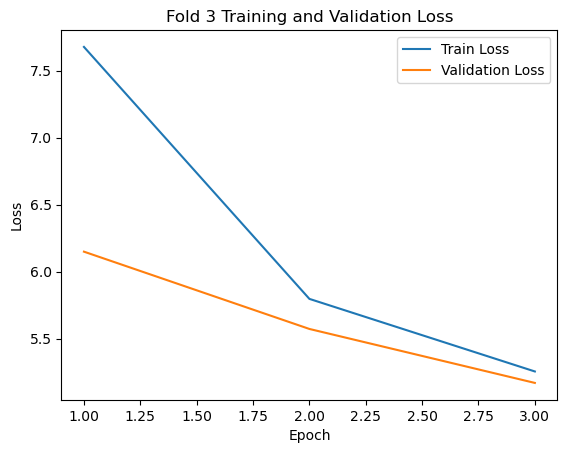

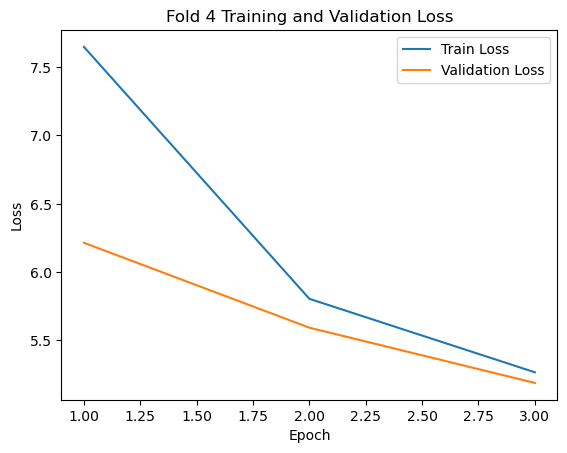

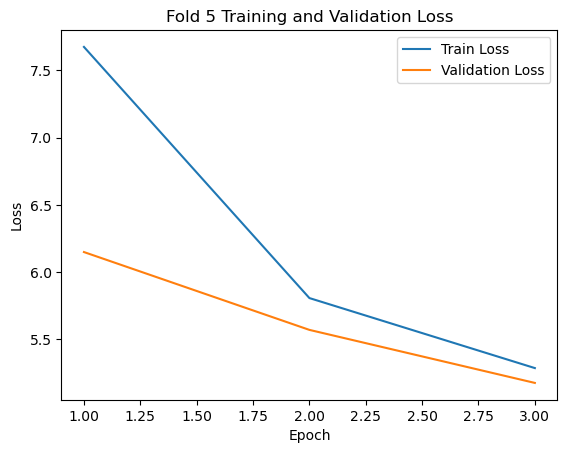

In [29]:
import matplotlib.pyplot as plt

for fold in range(k_folds):
    plt.figure()
    plt.plot(range(1, num_epochs + 1), fold_train_losses[fold], label="Train Loss")
    plt.plot(range(1, num_epochs + 1), fold_val_losses[fold], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Fold {fold + 1} Training and Validation Loss")
    plt.legend()
    plt.show()